# **와인 등급 분류 MLP 모델**

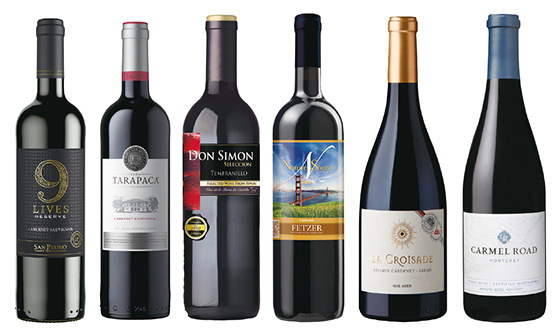

In [1]:
# 필요한 라이브러리 불러오기
!pip install koreanize_matplotlib
import koreanize_matplotlib
import pandas as pd; import numpy as np
import matplotlib.pyplot as plt
import numpy as np;  import seaborn as sns
from sklearn.metrics import log_loss, accuracy_score, confusion_matrix
import tensorflow as tf; from tensorflow import keras
from keras.models import Model, Sequential
from keras.layers import Input, Dense
import random
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 49.5 MB/s eta 0:00:00


In [3]:
df = pd.read_csv("와인품질.csv", encoding='cp949')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.6,0.645,0.03,1.90,0.086,14.0,57.0,0.99690,3.37,0.46,10.3,Bad
1,8.0,0.250,0.43,1.70,0.067,22.0,50.0,0.99460,3.38,0.60,11.9,Good
2,7.7,0.835,0.00,2.60,0.081,6.0,14.0,0.99750,3.30,0.52,9.3,Bad
3,8.3,0.850,0.14,2.50,0.093,13.0,54.0,0.99724,3.36,0.54,10.1,Bad
4,7.8,0.390,0.42,2.00,0.086,9.0,21.0,0.99526,3.39,0.66,11.6,Good
...,...,...,...,...,...,...,...,...,...,...,...,...
795,11.2,0.670,0.55,2.30,0.084,6.0,13.0,1.00000,3.17,0.71,9.5,Bad
796,9.1,0.660,0.15,3.20,0.097,9.0,59.0,0.99976,3.28,0.54,9.6,Bad
797,8.9,0.480,0.24,2.85,0.094,35.0,106.0,0.99820,3.10,0.53,9.2,Bad
798,9.4,0.340,0.37,2.20,0.075,5.0,13.0,0.99800,3.22,0.62,9.2,Bad


<Axes: xlabel='sulphates', ylabel='alcohol'>

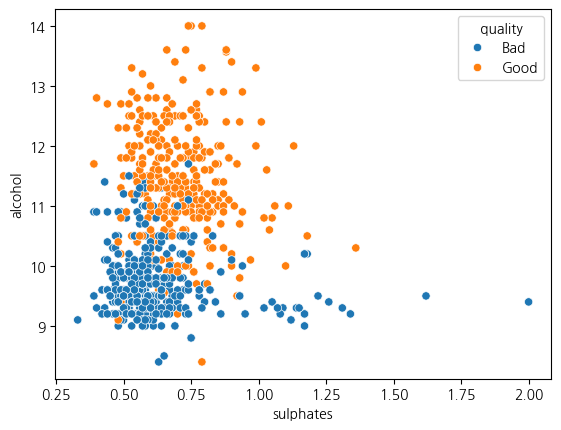

In [4]:
import seaborn as sns
sns.scatterplot(x=df["sulphates"], y=df["alcohol"], hue=df["quality"])

In [5]:
y=df["quality"]                   # 타깃
X=df.drop(["quality"], axis=1)    # 입력
# 타겟을 원핫 인코딩
y_oh = pd.get_dummies(y).astype(int)  # 알파벳순으로 Bad가 0번 열, Good이 1번 열
y_oh

,Bad,Good
0,1,0
1,0,1
2,1,0
3,1,0
4,0,1
...,...,...
795,1,0
796,1,0
797,1,0
798,1,0


# 모형설정과 컴파일

In [6]:
SEED = 42; np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

x_train, x_test, y_train, y_test = train_test_split(X, y_oh, test_size=0.2, random_state=42)

WINE=Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(16, activation='relu'),
    Dense(16, activation='relu'),
    Dense(2,  activation='softmax') ])

WINE.summary()

WINE.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# 조기종료 콜백
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True )

# 학습 시작
history=WINE.fit(x_train, y_train, epochs=300, validation_data=(x_test, y_test), callbacks=[early_stop])


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 770 (3.01 KB)

 Trainable params: 770 (3.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.5875 - loss: 0.9183 - val_accuracy: 0.6500 - val_loss: 0.7305
Epoch 2/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6469 - loss: 0.6432 - val_accuracy: 0.6812 - val_loss: 0.7089
Epoch 3/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6625 - loss: 0.6176 - val_accuracy: 0.6812 - val_loss: 0.6849
Epoch 4/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6703 - loss: 0.6012 - val_accuracy: 0.6875 - val_loss: 0.6651
Epoch 5/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6766 - loss: 0.5915 - val_accuracy: 0.6938 - val_loss: 0.6541
Epoch 6/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6734 - loss: 0.5837 - val_accuracy: 0.6938 - val_loss: 0.6475
Epoch 7/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6875 - loss: 0.5766 - val_accuracy: 0.6812 - val_loss: 0.6425
Epoch 8/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7047 - loss: 0.5711 - val_accuracy: 0.6812 - 

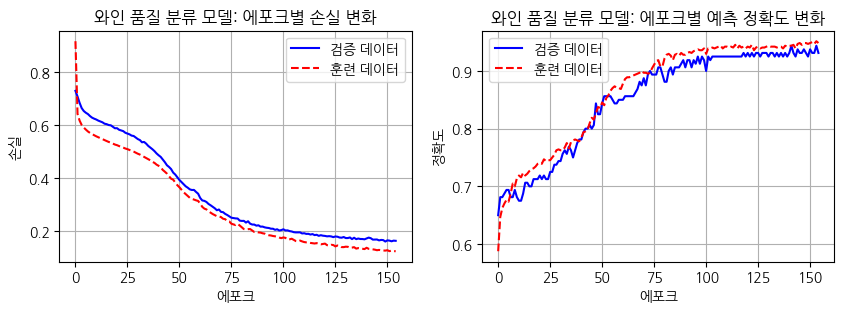

In [7]:
# 학습과정 시각화
plt.figure(figsize=(10, 3))
plt.subplot(1,2,1)
plt.plot(history.history['val_loss'], 'b-', label='검증 데이터')
plt.plot(history.history['loss'], 'r--', label='훈련 데이터')
plt.xlabel('에포크')
plt.ylabel('손실')
plt.title('와인 품질 분류 모델: 에포크별 손실 변화')
plt.legend(); plt.grid()
plt.subplot(1,2,2)
plt.plot(history.history['val_accuracy'], 'b-', label='검증 데이터')
plt.plot(history.history['accuracy'], 'r--', label='훈련 데이터')
plt.xlabel('에포크')
plt.ylabel('정확도')
plt.title('와인 품질 분류 모델: 에포크별 예측 정확도 변화')
plt.legend(); plt.grid()
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  


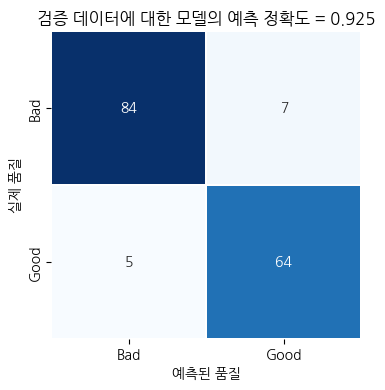

In [8]:
y_prob = WINE.predict(x_test)
y_pred = np.argmax(y_prob, axis=1)  # 예측된 클래스 레이블
class_labels=["Bad", "Good"]

import matplotlib.pyplot as plt; import numpy as np; import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

y_test_index=np.argmax(y_test,axis=1)
cm = confusion_matrix(y_test_index, y_pred)
acc = accuracy_score(y_test_index, y_pred)

# Confusion Matrix 시각화
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True,linewidths=0.1, cmap='Blues',cbar=None,
            xticklabels=class_labels, yticklabels=class_labels)

plt.ylabel('실제 품질'); plt.xlabel('예측된 품질')
plt.title(f'검증 데이터에 대한 모델의 예측 정확도 = {acc:.3f}')
plt.show()